In [ ]:
from pkg.mask.download_era5_mask_data import download_era5_for_climatology
from pkg.mask.climatology import compute_era5_climatology
from pkg.mask.download_era5_mask_data import unzip_surface_archives

In [2]:
%cd /Users/estakempf/Tech/Bachelorarbeit/graphcast-xai

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai


# Download Data for Mask

In [ ]:
# data for graphcast_small on the 18th of February 10:00 and 16:00 UTC (1979-2015)

download_era5_for_climatology(
    years=range(1979, 2016),
    month=2, day=18,
    times=["10:00", "16:00"],
    levels=13,
    grid=1.0,
    upload_to_gcs=False
)


In [ ]:
unzip_surface_archives("make_mask/data/mask_era5", suffix="_surface.zip")

In [3]:
# calculate average climatology 

clim = compute_era5_climatology(
    input_folder="make_mask/data/mask_era5",
    output_path="make_mask/data/era5_1979-2015_0218_climatology.nc",
    upload_to_gcs=False
)

📊 Processing era5_1979_0218_1000_1600_13lev_1p0deg_pressure.nc
🕒 Time shape: (2,) — values: ['1979-02-18T10:00:00.000000000' '1979-02-18T16:00:00.000000000']
📊 Processing era5_1980_0218_1000_1600_13lev_1p0deg_pressure.nc
🕒 Time shape: (2,) — values: ['1980-02-18T10:00:00.000000000' '1980-02-18T16:00:00.000000000']
📊 Processing era5_1981_0218_1000_1600_13lev_1p0deg_pressure.nc
🕒 Time shape: (2,) — values: ['1981-02-18T10:00:00.000000000' '1981-02-18T16:00:00.000000000']
📊 Processing era5_1982_0218_1000_1600_13lev_1p0deg_pressure.nc
🕒 Time shape: (2,) — values: ['1982-02-18T10:00:00.000000000' '1982-02-18T16:00:00.000000000']
📊 Processing era5_1983_0218_1000_1600_13lev_1p0deg_pressure.nc
🕒 Time shape: (2,) — values: ['1983-02-18T10:00:00.000000000' '1983-02-18T16:00:00.000000000']
📊 Processing era5_1984_0218_1000_1600_13lev_1p0deg_pressure.nc
🕒 Time shape: (2,) — values: ['1984-02-18T10:00:00.000000000' '1984-02-18T16:00:00.000000000']
📊 Processing era5_1985_0218_1000_1600_13lev_1p0deg_p

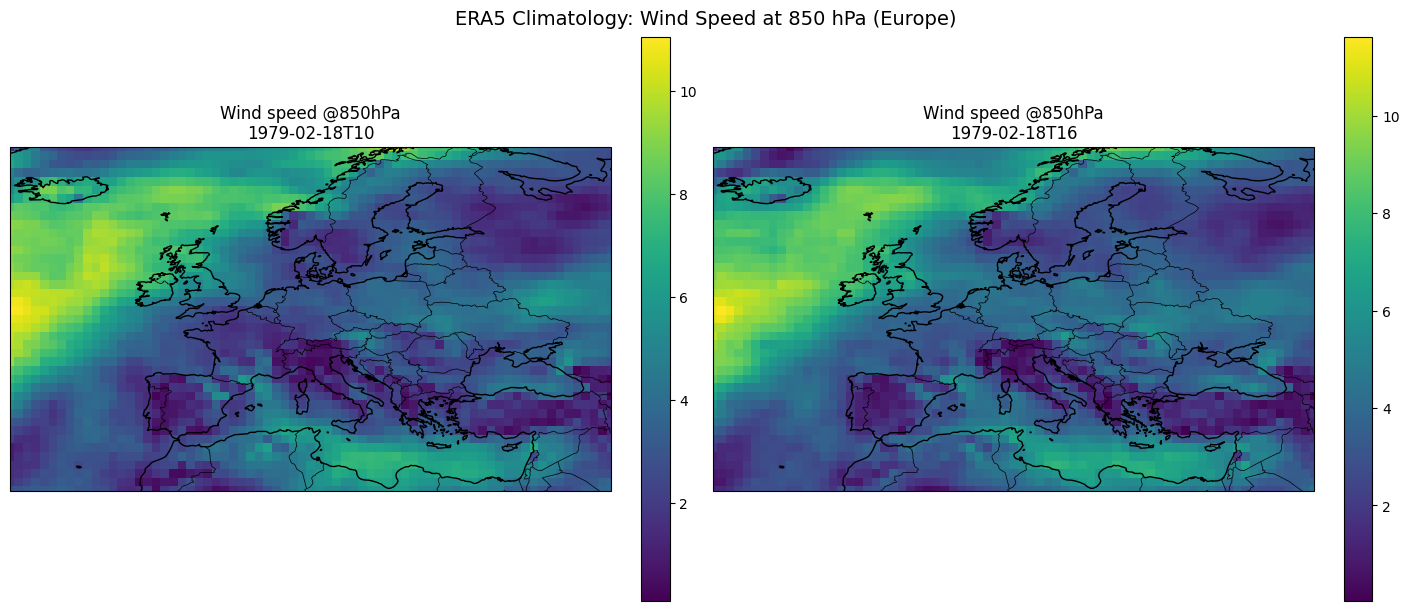

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load dataset
ds = xr.open_dataset("make_mask/data/era5_1979-2015_0218_climatology.nc")

# Compute wind speed at 850 hPa
u_850 = ds['u'].sel(pressure_level=850)
v_850 = ds['v'].sel(pressure_level=850)
wind_speed_850 = np.sqrt(u_850**2 + v_850**2)

# Crop to Europe
wind_europe = wind_speed_850.sel(lat=slice(70, 30), lon=slice(-25, 45))

# Plot with Cartopy
fig, axs = plt.subplots(1, 2, figsize=(14, 6),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        constrained_layout=True)

for i, time_label in enumerate(ds.time.values):
    ax = axs[i]
    im = wind_europe.isel(time=i).plot.pcolormesh(
        ax=ax,
        cmap='viridis',
        transform=ccrs.PlateCarree(),
        add_colorbar=True,
        add_labels=False
    )
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(f"Wind speed @850hPa\n{np.datetime_as_string(time_label, unit='h')}")
    ax.set_extent([-25, 45, 30, 70], crs=ccrs.PlateCarree())

plt.suptitle("ERA5 Climatology: Wind Speed at 850 hPa (Europe)", fontsize=14)
plt.show()

